In [11]:
model_name = "Qwen/Qwen3-4B-Instruct-2507"

In [26]:
from transformers import AutoTokenizer

In [27]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [28]:
tokens = [4913,   9217,    788,    330,  15686,   2966,   9207, 151645, 198]

In [29]:
tokenizer.decode(tokens)

'{"answer": "Bedroom"}<|im_end|>\n'

In [2]:
from transformers import AutoConfig

In [3]:
config = AutoConfig.from_pretrained(model_name)

In [14]:
config.hidden_size

2560

In [18]:
151_936 * 2560 / 10 ** 9

0.38895616

In [30]:
weights = {}

In [12]:
from transformers import AutoModelForCausalLM

In [13]:
model = AutoModelForCausalLM.from_pretrained(model_name)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [14]:
init_embs = model.get_input_embeddings()

In [62]:
init_embs.weight.std()

tensor(0.0217, grad_fn=<StdBackward0>)

In [1]:
from safetensors import safe_open

file_path = "../checkpoints/rmt_qwen_4b_lora_frozen_mem/stage_0/checkpoint-940/adapter_model.safetensors"
weights = {}
# Open the file without loading data into memory
# framework="pt" (PyTorch), "np" (Numpy), "tf" (TensorFlow), or "flax"
with safe_open(file_path, framework="pt", device="cpu") as f:
    for key in f.keys():
        weights[key] = f.get_tensor(key)

In [2]:
weights.keys()

dict_keys(['base_model.model.memory_cell.memory', 'base_model.model.model.layers.0.mlp.down_proj.lora_A.weight', 'base_model.model.model.layers.0.mlp.down_proj.lora_B.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.weight', 'base_model.model.model.layers.1.mlp.down_proj.l

In [6]:
weights['base_model.model.model.layers.0.mlp.down_proj.lora_A.weight'].mean()

tensor(4.4810e-06)

In [4]:
import matplotlib.pyplot as plt

In [5]:
import torch

In [6]:
weights['base_model.model.memory_cell.memory'].mean(1)

tensor([-0.0027,  0.0374, -0.0140, -0.0248, -0.0149,  0.0021, -0.0043,  0.0233,
         0.0110, -0.0010,  0.0012, -0.0024,  0.0021,  0.0355,  0.0124,  0.0219,
        -0.0172, -0.0023, -0.0264, -0.0099,  0.0125,  0.0009, -0.0008, -0.0094,
         0.0005, -0.0457, -0.0062,  0.0298, -0.0064, -0.0391,  0.0176, -0.0476])

(array([54., 70., 65., 60., 71., 77., 79., 77., 83., 72., 74., 77., 71.,
        90., 81., 86., 76., 78., 68., 73., 66., 78., 85., 74., 63., 65.,
        70., 71., 46., 65., 46., 56., 46., 33., 39., 30., 24., 21., 22.,
        16., 12., 13.,  9.,  6., 11.,  3.,  3.,  2.,  2.,  1.]),
 array([0.        , 0.01269458, 0.02538916, 0.03808374, 0.05077833,
        0.0634729 , 0.07616749, 0.08886207, 0.10155665, 0.11425123,
        0.12694581, 0.13964039, 0.15233497, 0.16502956, 0.17772414,
        0.19041872, 0.2031133 , 0.21580788, 0.22850247, 0.24119705,
        0.25389162, 0.26658621, 0.27928078, 0.29197538, 0.30466995,
        0.31736454, 0.33005911, 0.34275371, 0.35544828, 0.36814287,
        0.38083744, 0.39353204, 0.40622661, 0.41892117, 0.43161577,
        0.44431034, 0.45700493, 0.4696995 , 0.4823941 , 0.49508867,
        0.50778323, 0.52047783, 0.53317243, 0.54586703, 0.55856156,
        0.57125616, 0.58395076, 0.59664536, 0.60933989, 0.62203449,
        0.63472909]),
 <BarContainer

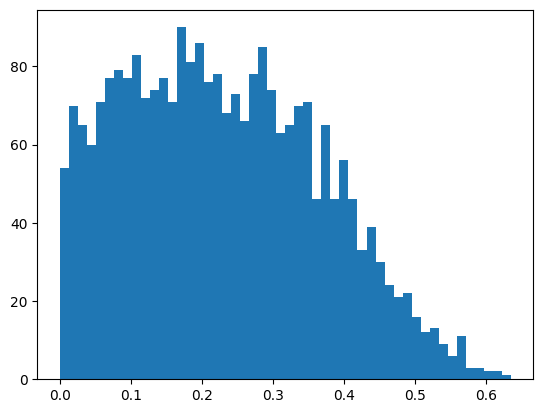

In [7]:
plt.hist(torch.log10(weights['base_model.model.memory_cell.memory'][0].abs() + 1), bins=50)

In [23]:
def get_num_flop_per_token(num_params: int, model_config, seq_len) -> int:
    l, h, q, t = (
        model_config.num_hidden_layers,
        model_config.hidden_size / model_config.head_dim,
        config.head_dim,
        seq_len,
    )
    # Reasoning behind the factor of 12 for the self-attention part of the formula:
    # 1. each self-attention has 2 matmul in the forward and 4 in the backward (6)
    # 2. the flash attention does 1 more matmul recomputation in the backward
    #    but recomputation should not be counted in calculating MFU           (+0)
    # 3. each matmul performs 1 multiplication and 1 addition                 (*2)
    # 4. we follow the convention and do not account for sparsity in causal attention
    flop_per_token = 6 * num_params + 12 * l * h * q * t
 
    return flop_per_token
 
 
num_flop_per_token = get_num_flop_per_token(
        4_088_692_224 - 151_936 * 2560 * 2,
        config,
        512,
    )
 
wps = 10.73 * 10 ** 6 / 11.35 / 60
gpu_peak_flops = 312 * 10 ** 12
# model FLOPS utilization
# For its definition and calculation, please refer to the PaLM paper:
# https://arxiv.org/abs/2204.02311
mfu = 100 * num_flop_per_token * wps / gpu_peak_flops

In [24]:
mfu

103.17767483655258

In [3]:
import json
import logging
import os
from dataclasses import dataclass, field
from typing import Optional

import torch
from datasets import load_dataset
from modeling_rmt import RMTQwen3Config, RMTQwen3ForCausalLM
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoTokenizer
from trl import ModelConfig, SFTConfig, SFTTrainer, TrlParser
from trl.trainer.sft_trainer import DataCollatorForLanguageModeling

/workspace-SR004.nfs2/kurkin/envs/kurkin_313_torch/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR004.nfs2/kurkin/envs/kurkin_313_torch/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/workspace-SR004.nfs2/kurkin/envs/kurkin_313_torch/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:

In [4]:

@dataclass
class RMTArgs:
    segment_size: int = field(metadata={"help": "Segment size for RMT."})
    num_mem_tokens: int = field(default=16, metadata={"help": "Number of memory tokens."})
    max_n_segments: Optional[int] = field(default=None, metadata={"help": "Maximum number of segments to train on."})
    k2: int = field(default=-1, metadata={"help": "BPTT unroll steps for RMT."})
    segment_alignment: Optional[str] = field(default=None, metadata={"help": "Segment alignment strategy."})
    sliding_window: bool = field(default=False, metadata={"help": "Whether to enable sliding window alignment."})



In [5]:


@dataclass
class DatasetArgs:
    dataset_name: str
    subset: str = field(default="default", metadata={"help": "Dataset subset."})
    split: str = field(default="train", metadata={"help": "Dataset split."})
    val_split: str = field(default="val", metadata={"help": "Dataset validation split."})
    system_prompt: Optional[str] = "You are a helpful AI assistant."
    task_prompt: Optional[str] = "Answer with a single word or number."
    subsample_train: float = field(default=1.00, metadata={"help": "Subsample train set."})
    

In [6]:
ds_args = DatasetArgs("../dataset/hf_main_1mv_train_full")
task_prompt = """
Format your final answer with a {"answer": <value>}, where <value> is:
    - A **single room name** (e.g., 'Kitchen') for location answers.
    - A **number** (e.g., '3') for counting answers.
    - A **single person name** (e.g., 'Michael') for people answers or 'Nobody' if no person satisfies given conditions.
"""

In [7]:
ds_args.task_prompt = task_prompt

In [8]:
import json
from typing import List, Dict, Any

def preprocess_function(example, ds_args: "DatasetArgs", tokenizer, segment_size: int) -> Dict[str, Any]:
    """
    Segments:
        [S0 (padded to segment_size), S1 (padded), ..., Sk (padded), S_final (assistant_prefix + completion, NOT padded)]

    S0..Sk together contain:
        system + user (chat template, pre-assistant area) + steps (whole list broken into pieces)

    S_final contains:
        assistant_prefix (chat template) + completion (json answer + eos)
    """
    # 1) Build user message text (task prompt + question)
    user_content_parts: List[str] = []
    if getattr(ds_args, "task_prompt", None):
        user_content_parts.append(ds_args.task_prompt)
    user_content_parts.append(example["question"])
    user_content = "\n".join(user_content_parts)

    # 2) Messages up to assistant (no assistant content yet)
    messages = []
    if getattr(ds_args, "system_prompt", None):
        messages.append({"role": "system", "content": ds_args.system_prompt})
    messages.append({"role": "user", "content": user_content})

    # 3) We need to split the chat-template tokens into:
    #    - pre_assistant_tokens: everything BEFORE the assistant header/prefix
    #    - assistant_prefix_tokens: the assistant header/prefix itself (no assistant content)
    #
    #    Robust approach:
    #      A) Template with add_generation_prompt=False  → ends right after the user content (no assistant header)
    #      B) Template with add_generation_prompt=True + dummy assistant content → assistant header + dummy content
    #      C) Find where dummy content begins; tokens before it contain both pre_assistant + assistant_prefix.
    #         Then subtract (A) from the front to isolate the assistant prefix.
    #
    #   NOTE: This avoids relying on EOS positioning or tokenizer-specific special IDs.
    baseline = tokenizer.apply_chat_template(
        messages, add_generation_prompt=False, tokenize=True, return_dict=True
    )
    with_gen_and_dummy = tokenizer.apply_chat_template(
        messages + [{"role": "assistant", "content": "DUMMY"}],
        add_generation_prompt=True, tokenize=True, return_dict=True
    )

    base_ids = list(baseline.input_ids)  # up to end of user
    gen_dummy_ids = list(with_gen_and_dummy.input_ids)  # includes assistant prefix + tokens for "DUMMY"

    # Tokenize the dummy string alone to locate its start reliably.
    dummy_only = tokenizer("DUMMY", add_special_tokens=False).input_ids

    # Find the dummy content start inside gen_dummy_ids
    # We search for the first exact match of the dummy_only sequence.
    def find_subseq(haystack: List[int], needle: List[int]) -> int:
        if not needle:
            return -1
        L, N = len(haystack), len(needle)
        for i in range(max(0, len(base_ids)), L - N + 1):  # start search at least after baseline
            if haystack[i:i+N] == needle:
                return i
        return -1

    dummy_start = find_subseq(gen_dummy_ids, dummy_only)
    if dummy_start == -1:
        # Fallback: if we can't find it, we treat the entire difference as assistant prefix.
        # This is rare, but keeps behavior defined.
        pre_assistant_tokens = base_ids
        assistant_prefix_tokens = gen_dummy_ids[len(base_ids):]
    else:
        # Tokens before dummy_start contain: base_ids + assistant_prefix_tokens
        assert len(gen_dummy_ids) >= dummy_start
        pre_plus_prefix = gen_dummy_ids[:dummy_start]
        # Split into (pre-assistant, assistant_prefix) using base_ids length.
        assert len(pre_plus_prefix) >= len(base_ids)
        pre_assistant_tokens = pre_plus_prefix[:len(base_ids)]
        assistant_prefix_tokens = pre_plus_prefix[len(base_ids):]

    # Sanity: pre_assistant_tokens should equal base_ids (they should!),
    # but keep the variable for clarity.
    # Now, we will construct:
    #   prompt_tokens_before_assistant = pre_assistant_tokens + steps_tokens
    #   completion_segment = assistant_prefix_tokens + completion_tokens (+ eos)
    prompt_tokens_before_assistant = list(pre_assistant_tokens)

    # 4) Steps
    steps = example["sequence_json"].replace("'", '"')
    if isinstance(steps, str):
        steps = json.loads(steps)
    # Ensure steps are strings with a trailing newline (as the original code)
    step_texts = [str(s) + "\n" for s in steps]

    # Tokenize steps one-by-one, then append into the prompt area (before assistant)
    tokenized_steps = tokenizer(step_texts, add_special_tokens=False)
    for step_ids in tokenized_steps.input_ids:
        prompt_tokens_before_assistant.extend(step_ids)

    # 5) Pack pre-assistant prompt content into fixed-size segments, padding each to segment_size
    input_ids: List[int] = []
    num_segments = 0

    def flush_segment(seg: List[int], pad_to: int, pad_id: int):
        nonlocal input_ids, num_segments
        if not seg:
            return
        if len(seg) < pad_to:
            seg = seg + [pad_id] * (pad_to - len(seg))
        input_ids.extend(seg)
        num_segments += 1

    # Greedy packer for the prompt content (pre-assistant + steps)
    current_seg: List[int] = []
    for tid in prompt_tokens_before_assistant:
        if len(current_seg) == segment_size:
            flush_segment(current_seg, segment_size, tokenizer.pad_token_id)
            current_seg = []
        current_seg.append(tid)
    # If there's remaining content in the current segment, pad and flush
    if current_seg:
        flush_segment(current_seg, segment_size, tokenizer.pad_token_id)

    # 6) Build the completion segment (NOT padded):
    #    assistant_prefix + JSON completion + eos
    completion_text = json.dumps({"answer": example["answer"]})
    completion_ids = tokenizer(completion_text, add_special_tokens=False).input_ids
    eos_id = tokenizer.eos_token_id
    if eos_id is None:
        raise ValueError("tokenizer.eos_token_id is None; please set eos token.")
    completion_segment = list(assistant_prefix_tokens) + completion_ids + [eos_id]

    # Append completion segment WITHOUT padding and count exactly one segment
    input_ids.extend(completion_segment)
    num_segments += 1  # final segment

    # 7) Build completion mask:
    #    - mask 0 over all padded prompt segments
    #    - mask 1 over the entire final (assistant_prefix + completion) segment
    total_prompt_len = len(input_ids) - len(completion_segment) + len(assistant_prefix_tokens)
    completion_mask = [0] * total_prompt_len + [1] * (len(input_ids) - total_prompt_len)

    return {
        "input_ids": input_ids,
        "completion_mask": completion_mask,
        "num_segments": num_segments,
        "length": len(input_ids),
    }


In [9]:
raw_train_ds = load_dataset(ds_args.dataset_name, ds_args.subset)[ds_args.split]

In [10]:
model_name_or_path = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

In [11]:
rmt_args = RMTArgs(segment_size=256)

In [12]:
processed_train_ds = raw_train_ds.map(
    lambda ex: preprocess_function(ex, ds_args, tokenizer, rmt_args.segment_size),
    remove_columns=raw_train_ds.column_names,
)

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map: 100%|██████████| 24000/24000 [00:32<00:00, 729.22 examples/s]


In [13]:
processed_df = processed_train_ds.to_pandas()

In [14]:
processed_df.describe()

,num_segments,length
count,24000.000000,24000.000000
mean,3.199917,573.450417
std,1.166193,298.552915
min,2.000000,266.000000
25%,2.000000,266.000000
50%,3.000000,522.000000
75%,4.000000,779.000000
max,5.000000,1035.000000


In [15]:
processed_df['num_segments'].value_counts()

num_segments
2    9600
3    4802
5    4800
4    4798
Name: count, dtype: int64

In [20]:
short_input = processed_df[processed_df['num_segments'] == 3].sample(1)

In [17]:
tokenizer.decode(short_input.input_ids.tolist()[0])

'<|im_start|>system\nYou are a helpful AI assistant.<|im_end|>\n<|im_start|>user\n\nFormat your final answer with a {"answer": <value>}, where <value> is:\n    - A **single room name** (e.g., \'Kitchen\') for location answers.\n    - A **number** (e.g., \'3\') for counting answers.\n    - A **single person name** (e.g., \'Michael\') for people answers or \'Nobody\' if no person satisfies given conditions.\n\nHow many different rooms did Daniel visit?<|im_end|>\n{\'step_id\': 1, \'rooms\': {\'Kitchen\': [\'John\', \'Daniel\'], \'Bathroom\': [\'Sandra\'], \'Garden\': [], \'Office\': [], \'Bedroom\': [\'Mary\', \'Michael\'], \'Hallway\': []}}\n{\'step_id\': 2, \'rooms\': {\'Kitchen\': [\'John\', \'Daniel\'], \'Bathroom\': [], \'Garden\': [], \'Office\': [], \'Bedroom\': [\'Mary\', \'Michael\'], \'Hallway\': [\'Sandra\']}}\n<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|

In [21]:
tokenizer.decode(short_input.completion_mask.tolist()[0] * short_input.input_ids.tolist()[0])

'!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!{"answer": "Office"}<|im_end|>'

In [63]:
long_input = processed_df[processed_df['num_segments'] == 7].sample(1)

In [64]:
long_input.completion_mask.tolist()[0]

array([0, 0, 0, ..., 1, 1, 1], shape=(1163,))

In [66]:
input_ids = long_input.input_ids.tolist()[0]

In [67]:
decoded_ids = tokenizer.batch_decode(input_ids)

In [68]:
pprint_array(decoded_ids, rmt_args.segment_size)

<|im_start|> system 
 You  are  a  helpful  AI  assistant . <|im_end|> 
 <|im_start|> user 

 Format  your  final  answer  with  a  {" answer ":  < value > },  where  < value >  is :
      -  A  ** single  room  name **  ( e .g .,  ' Kitchen ')  for  location  answers .
      -  A  ** number **  ( e .g .,  ' 3 ')  for  counting  answers .
      -  A  ** single  person  name **  ( e .g .,  ' Michael ')  for  people  answers  or  ' Nobody '  if  no  person  satisfies  given  conditions .

 Which  room  was  crowded  ( 3  or  more  people  in  one  room )  for  the  most  steps ? <|im_end|> 
 {' step _id ':   1 ,  ' rooms ':  {' Kitchen ':  [],  ' B athroom ':  [],  ' G arden ':  [' S andra '],  ' Office ':  [],  ' Bed room ':  [' John ',  ' Daniel ',  ' Michael '],  ' Hall way ':  [' Mary '] }}
 {' step _id ':   2 ,  ' rooms ':  {' Kitchen ':  [],  ' B athroom ':  [],  ' G
arden ':  [' S andra ',  ' Daniel '],  ' Office ':  [],  ' Bed room ':  [' John ',  ' Michael '],  ' Hall way ':  ['

In [69]:
pprint_array(input_ids, rmt_args.segment_size)

151644 8948 198 2610 525 264 10950 15235 17847 13 151645 198 151644 872 271 4061 697 1590 4226 448 264 5212 9217 788 366 957 29 2137 1380 366 957 29 374 510 262 481 362 3070 15338 3054 829 334 320 68 1302 2572 364 84583 863 369 3728 11253 624 262 481 362 3070 4082 334 320 68 1302 2572 364 18 863 369 25009 11253 624 262 481 362 3070 15338 1697 829 334 320 68 1302 2572 364 25516 863 369 1251 11253 476 364 56713 6 421 902 1697 67901 2661 4682 382 23085 3054 572 38213 320 18 476 803 1251 304 825 3054 8 369 279 1429 7354 30 151645 198 13608 9520 842 1210 220 16 11 364 9750 1210 5360 84583 1210 10071 364 33 77832 1210 10071 364 38 8341 1210 2509 50 23274 4089 364 23914 1210 10071 364 15686 2966 1210 2509 13079 516 364 40586 516 364 25516 4089 364 71845 3117 1210 2509 41484 660 11248 13608 9520 842 1210 220 17 11 364 9750 1210 5360 84583 1210 10071 364 33 77832 1210 10071 364 38
8341 1210 2509 50 23274 516 364 40586 4089 364 23914 1210 10071 364 15686 2966 1210 2509 13079 516 364 25516 4089 3

In [11]:
raw_df = raw_train_ds.to_pandas()

In [12]:
raw_df['seq_len'].value_counts()

seq_len
1     4800
16    4800
2     4800
4     4800
8     4800
Name: count, dtype: int64

In [50]:
row = raw_df[raw_df['seq_len'] == 16].sample(1)

In [56]:
q = row['full_question'].values

In [28]:
df = processed_train_ds.to_pandas()

In [62]:
df['num_segments'].value_counts()

num_segments
3    9600
8    4800
4    4800
5    4800
Name: count, dtype: int64

In [79]:
sample_ids = df[df['num_segments'] == 8].sample(1)["input_ids"].values[0]

In [80]:
sample_text = tokenizer.decode(sample_ids)

In [81]:
from pprint import pprint

In [82]:
pprint(sample_text)

('<|im_start|>system\n'
 'You are a helpful AI assistant.<|im_end|>\n'
 '<|im_start|>user\n'
 'Answer with a single word or number.\n'
 'How many different rooms did Michael '
 "visit?<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftex

In [27]:
input_ids = processed_train_ds[5]['input_ids']

In [17]:
def pprint_array(arr, X):
    for i in range(0, len(arr), X):
        line = " ".join(str(arr[j]) for j in range(i, min(i+X, len(arr))))
        print(line)


In [28]:
pprint_array(input_ids, rmt_args.segment_size)

151644 8948 198 2610 525 264 10950 15235 17847 13 151645 198 151644 872 271 4061 697 1590 4226 448 264 5212 9217 788 366 957 29 2137 1380 366 957 29 374 510 262 481 362 3070 15338 3054 829 334 320 68 1302 2572 364 84583 863 369 3728 11253 624 262 481 362 3070 4082 334 320 68 1302 2572 364 18 863 369 25009 11253 624 262 481 362 3070 15338 1697 829 334 320 68 1302 2572 364 25516 863 369 1251 11253 476 364 56713 6 421 902 1697 67901 2661 4682 382 4340 1657 12026 1033 4287 518 3019 220 16 30 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151643 151

In [29]:
df['num_segments'].value_counts()

num_segments
3    9600
8    4800
4    4800
5    4800
Name: count, dtype: int64

<Axes: >

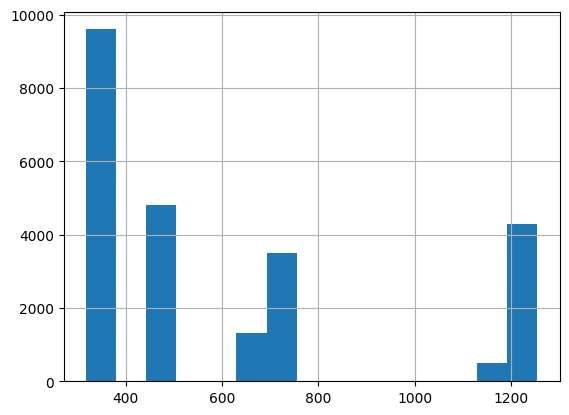

In [ ]:
df['length'].hist(bins=15)  

In [5]:
config = RMTQwen3Config.from_pretrained(
    model_name_or_path,
    segment_size=rmt_args.segment_size,
    max_n_segments=rmt_args.max_n_segments,
    num_mem_tokens=rmt_args.num_mem_tokens,
    segment_alignment=rmt_args.segment_alignment,
    k2=rmt_args.k2,
    sliding_window=rmt_args.sliding_window,
    local_files_only=True,
)


You are using a model of type qwen3 to instantiate a model of type rmt-qwen3. This is not supported for all configurations of models and can yield errors.


In [6]:
model = RMTQwen3ForCausalLM.from_pretrained(
    model_name_or_path,
    config=config,
    dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    local_files_only=True,
)

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 44.53it/s]
Some weights of RMTQwen3ForCausalLM were not initialized from the model checkpoint at Qwen/Qwen3-4B-Instruct-2507 and are newly initialized: ['memory.memory']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
peft_config = LoraConfig(
        r=32,
        lora_alpha=32,
        lora_dropout=0.05,
        modules_to_save=["memory"],
        target_modules="all-linear",
        task_type=TaskType.CAUSAL_LM,
        bias="none",
    )


In [8]:
peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()

trainable params: 66,101,248 || all params: 4,088,610,304 || trainable%: 1.6167


In [16]:
peft_model.memory

Parameter containing:
tensor([[-2.1810e+08,  3.6198e-10,  2.0204e+38,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-6.4852e+17,  3.6198e-10,  2.0204e+38,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]], dtype=torch.bfloat16, requires_grad=True)

In [9]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"LoRA parameter: {name}, shape: {param.shape}")

LoRA parameter: model.layers.0.self_attn.q_proj.lora_A.default.weight, shape: torch.Size([32, 2560])
LoRA parameter: model.layers.0.self_attn.q_proj.lora_B.default.weight, shape: torch.Size([4096, 32])
LoRA parameter: model.layers.0.self_attn.k_proj.lora_A.default.weight, shape: torch.Size([32, 2560])
LoRA parameter: model.layers.0.self_attn.k_proj.lora_B.default.weight, shape: torch.Size([1024, 32])
LoRA parameter: model.layers.0.self_attn.v_proj.lora_A.default.weight, shape: torch.Size([32, 2560])
LoRA parameter: model.layers.0.self_attn.v_proj.lora_B.default.weight, shape: torch.Size([1024, 32])
LoRA parameter: model.layers.0.self_attn.o_proj.lora_A.default.weight, shape: torch.Size([32, 4096])
LoRA parameter: model.layers.0.self_attn.o_proj.lora_B.default.weight, shape: torch.Size([2560, 32])
LoRA parameter: model.layers.0.mlp.gate_proj.lora_A.default.weight, shape: torch.Size([32, 2560])
LoRA parameter: model.layers.0.mlp.gate_proj.lora_B.default.weight, shape: torch.Size([9728, 3

In [10]:
peft_model.merge_and_unload()

RMTQwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_la